In [1]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt

In [2]:
# ============================================================
# PLL SIMULATORS
#
# Exact update ordering:
#
#   e      = theta - phi        # linearized phase detector
#   omega += i * e
#   phi   += omega + p * e      # uses NEW omega
#
# ============================================================

def phase_step_response(p, i, N=200, phase_step=1.0):
    """
    True carrier phase suddenly jumps by 'phase_step' radians.

    Returns:
        phi       PLL phase estimate
        error     detector phase error BEFORE each update
        omega     PLL frequency estimate
    """
    theta = phase_step
    phi = 0.0
    omega = 0.0

    phi_hist = []
    error_hist = []
    omega_hist = []

    for k in range(N):
        e = theta - phi

        error_hist.append(e)

        omega += i * e
        phi += omega + p * e

        phi_hist.append(phi)
        omega_hist.append(omega)

    return (
        np.array(phi_hist),
        np.array(error_hist),
        np.array(omega_hist),
    )


def frequency_step_response(p, i, N=200, frequency_step=0.02):
    """
    True carrier frequency suddenly changes by 'frequency_step'
    radians/symbol.

    That means true phase becomes a ramp:
        theta[k+1] = theta[k] + frequency_step

    Returns:
        phi        PLL phase estimate
        error      detector phase error BEFORE each update
        omega      PLL frequency estimate
        theta      true carrier phase
    """
    theta = 0.0
    phi = 0.0
    omega = 0.0

    phi_hist = []
    error_hist = []
    omega_hist = []
    theta_hist = []

    for k in range(N):
        # Carrier advances according to its new frequency offset
        theta += frequency_step

        e = theta - phi

        error_hist.append(e)

        omega += i * e
        phi += omega + p * e

        phi_hist.append(phi)
        omega_hist.append(omega)
        theta_hist.append(theta)

    return (
        np.array(phi_hist),
        np.array(error_hist),
        np.array(omega_hist),
        np.array(theta_hist),
    )


p = 0.2
i = 0.02

Closed-loop poles:
  0.890000+0.088882j   |z| = 0.894427
  0.890000-0.088882j   |z| = 0.894427

Small-signal loop is STABLE.

Approx natural frequency:  sqrt(i) = 0.1414 rad/symbol
Approx damping ratio:      zeta    = 0.7071


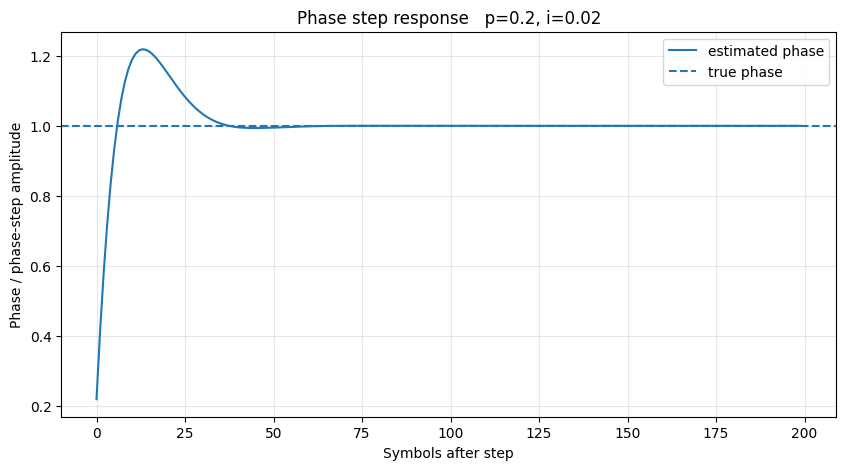

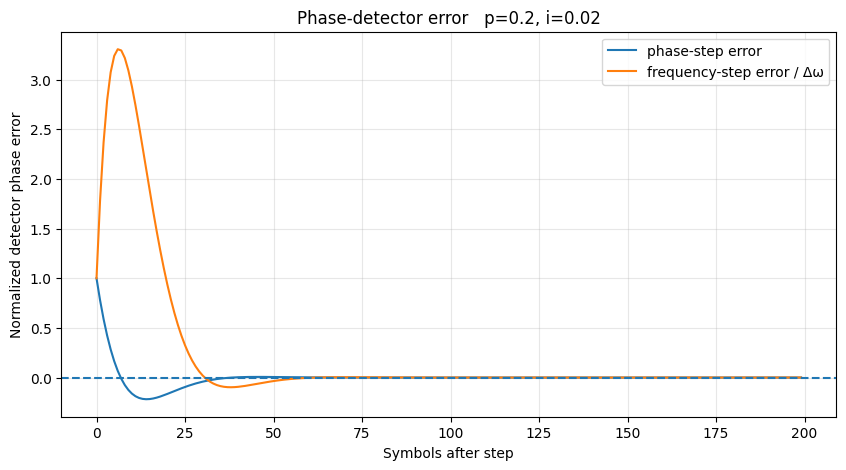

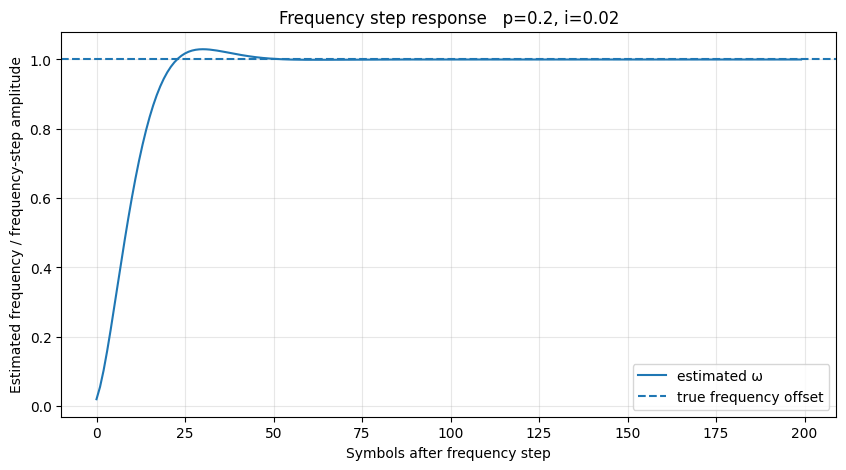

In [16]:

# ============================================================
# PLAY WITH THESE
# ============================================================

p = 0.2
i = 0.02

N = 200                  # number of symbols to simulate
phase_step = 1.0         # radians
frequency_step = 0.02    # radians / symbol


# ============================================================
# RUN SIMULATIONS
# ============================================================

phase_phi, phase_error, phase_omega = phase_step_response(
    p, i, N, phase_step
)

freq_phi, freq_error, freq_omega, freq_theta = frequency_step_response(
    p, i, N, frequency_step
)

k = np.arange(N)


# ============================================================
# SOME USEFUL LOOP NUMBERS
# ============================================================

# Exact closed-loop characteristic polynomial for this update order:
#
# z² - (2 - p - i) z + (1 - p) = 0
#
poles = np.roots([
    1,
    -(2 - p - i),
    1 - p
])

print(f"p = {p}")
print(f"i = {i}")
print()
print("Closed-loop poles:")
for pole in poles:
    print(f"  {pole:.6f}   |z| = {abs(pole):.6f}")

if np.all(np.abs(poles) < 1):
    print("\nSmall-signal loop is STABLE.")
else:
    print("\nWARNING: small-signal loop is UNSTABLE.")

# Approximate continuous-time intuition
if i > 0:
    wn_approx = np.sqrt(i)
    zeta_approx = p / (2 * np.sqrt(i))

    print(f"\nApprox natural frequency:  sqrt(i) = {wn_approx:.4f} rad/symbol")
    print(f"Approx damping ratio:      zeta    = {zeta_approx:.4f}")


# ============================================================
# PLOT 1 — PHASE STEP RESPONSE
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    k,
    phase_phi / phase_step,
    label="estimated phase"
)

plt.axhline(
    1.0,
    linestyle="--",
    label="true phase"
)

plt.xlabel("Symbols after step")
plt.ylabel("Phase / phase-step amplitude")
plt.title(
    f"Phase step response   p={p}, i={i}"
)
plt.grid(alpha=0.3)
plt.legend()
plt.show()


# ============================================================
# PLOT 2 — PHASE ERROR
#
# This plots the actual detector error e seen by:
#
#     omega += i * e
#
# before the state is updated.
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    k,
    phase_error / phase_step,
    label="phase-step error"
)

# Also show detector error during frequency acquisition.
#
# Normalize by frequency_step. The unit then roughly means
# "equivalent symbols of accumulated frequency mismatch".
plt.plot(
    k,
    freq_error / frequency_step,
    label="frequency-step error / Δω"
)

plt.axhline(
    0.0,
    linestyle="--"
)

plt.xlabel("Symbols after step")
plt.ylabel("Normalized detector phase error")
plt.title(
    f"Phase-detector error   p={p}, i={i}"
)
plt.grid(alpha=0.3)
plt.legend()
plt.show()


# ============================================================
# PLOT 3 — FREQUENCY STEP RESPONSE
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    k,
    freq_omega / frequency_step,
    label="estimated ω"
)

plt.axhline(
    1.0,
    linestyle="--",
    label="true frequency offset"
)

plt.xlabel("Symbols after frequency step")
plt.ylabel("Estimated frequency / frequency-step amplitude")
plt.title(
    f"Frequency step response   p={p}, i={i}"
)
plt.grid(alpha=0.3)
plt.legend()
plt.show()